In [ ]:
# sample_window = [10,15,17,19,21,23,25]
# sample_window_std = []   
# window_std_variances = {}

# for w in sample_window:
#     stds = []
    
#     for i in range(0, len(pressure) - w, w):
#         arr1 = pressure[i:i+w]
#         stds.append(np.std(arr1))     
#         window_std_variances[w] = np.var(stds)


# best_window = min(window_std_variances, key=window_std_variances.get)

# print("best window ", best_window)





best window  10


# 1.2mM

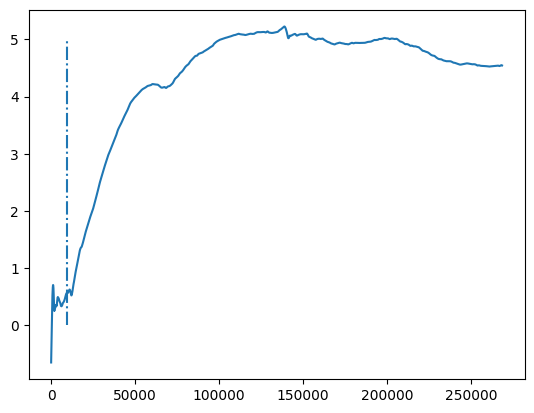

cropping at  9395


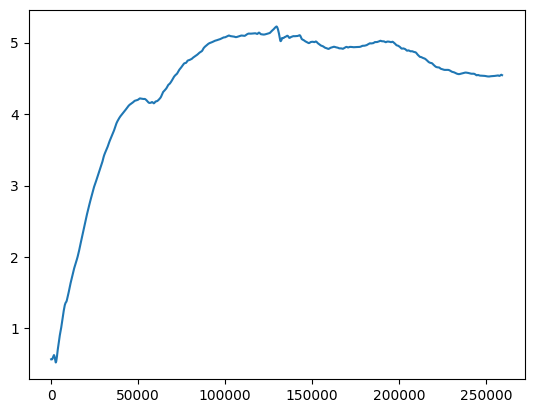

0.1960365581505114


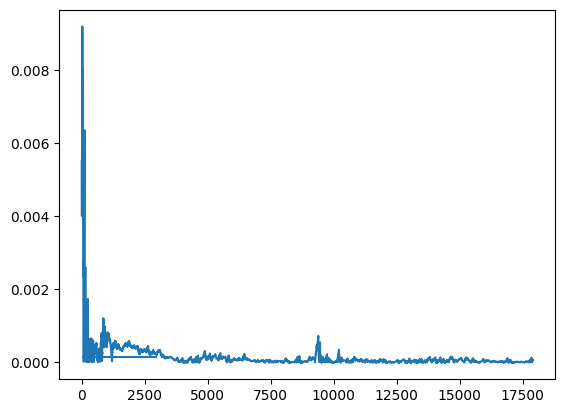

In [194]:
df = pd.read_csv( r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv")
time = df["Time (h)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 15  #no of samples  #10
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# 2.18mM

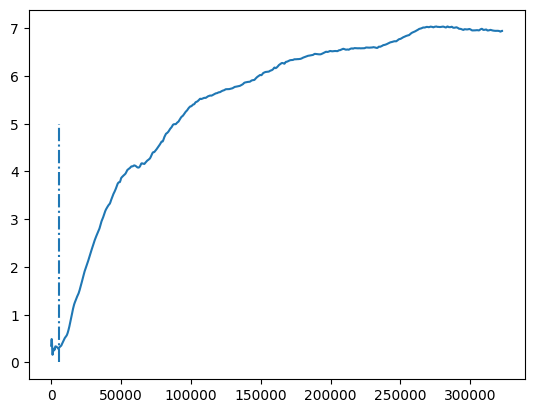

cropping at  5442


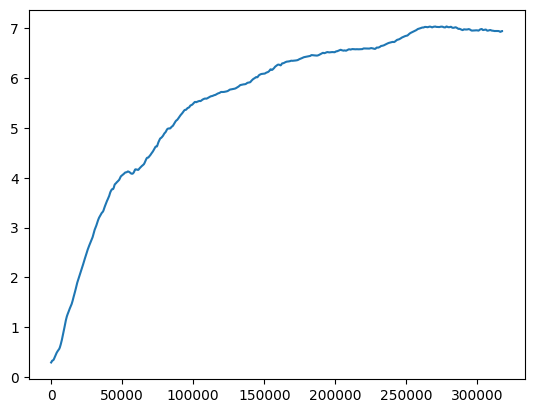

0.0687952424697118


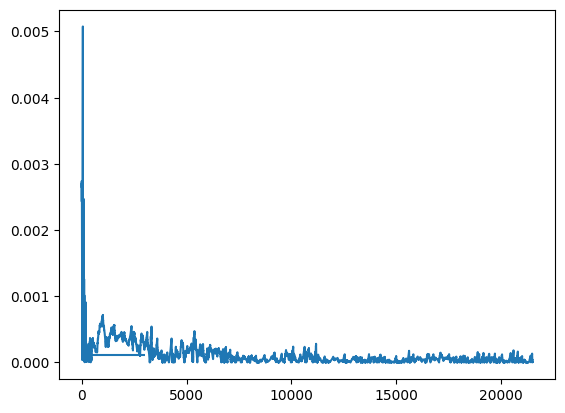

In [193]:
df = pd.read_csv( r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv")
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window =  15  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

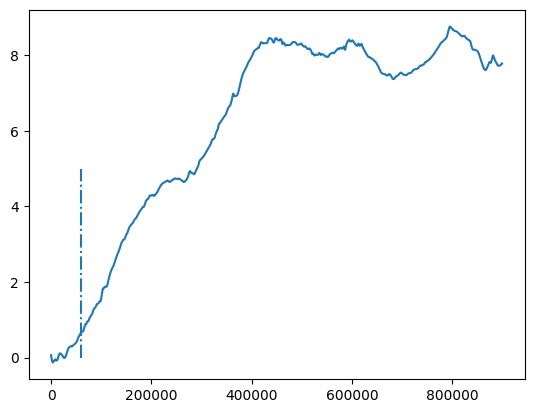

cropping at  59187


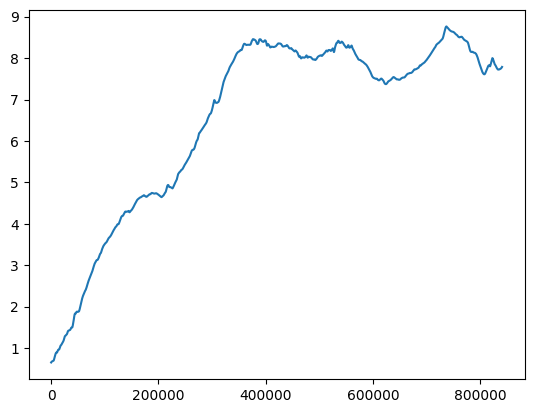

0.21349068193598794


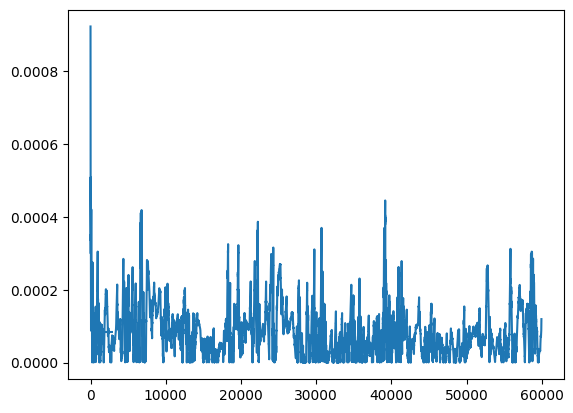

In [192]:
# Or try:
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 15 #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# Actual approach followed

# 2.5mM

Data length: 899397 samples
Testing window sizes for changepoint detection quality...

Optimal window size: 51
Best quality score: 0.780
Original fixed window: 25
Original window (25) score: 0.682


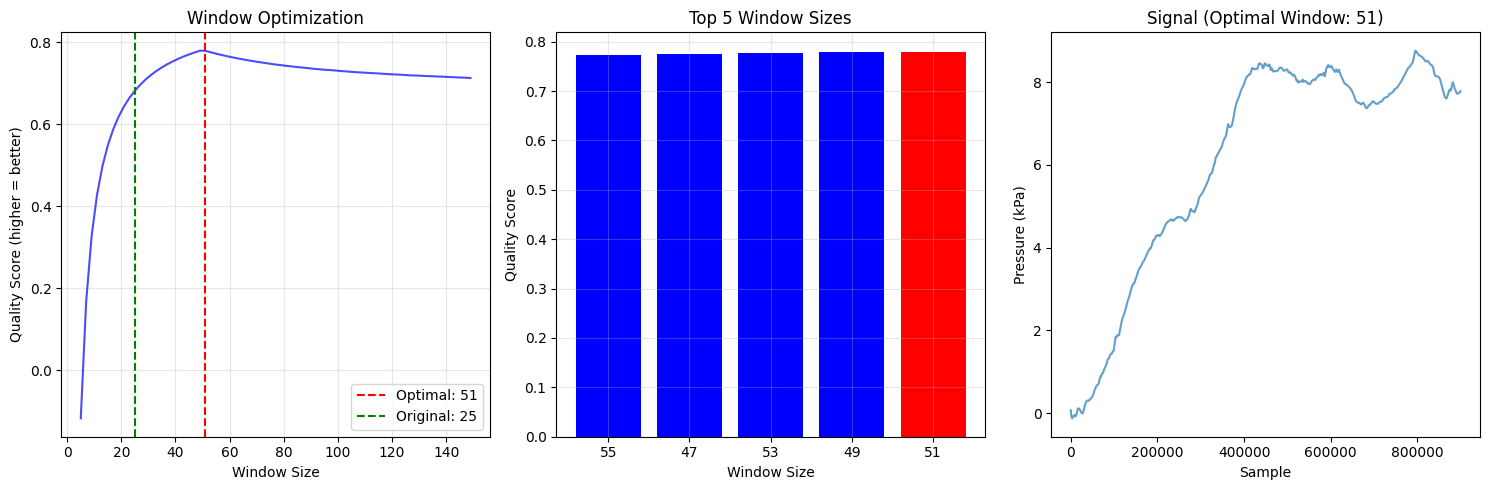


Selected window size: 51
Improvement over original: 14.3% better


In [167]:
# Approach 2: Optimization-based Window Selection
# This approach finds the window size that gives the BEST changepoint detection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data (keep your existing loading code)
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv",
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]

print(f"Data length: {len(pressure)} samples")



def test_changepoint_quality(pressure, window_size):
    """
    Test how well a window size works for changepoint detection
    Returns a quality score (higher = better)
    """
    window = int(window_size)
    
    # Skip if window is too small or too big
    if window < 5 or window > len(pressure)//5:
        return -999  # Very bad score
    
    try:
        # Your original algorithm
        std_all = []
        for i in range(0, len(pressure)-window, window):
            arr1 = pressure[i:i+window]
            std_all.append(np.std(arr1))
        
        # Need at least 3 windows to make sense
        if len(std_all) < 3:
            return -999
        
        mean_std = np.mean(std_all)
        threshold = mean_std + np.std(std_all)
        
        # Quality metrics:
        # 1. How well separated are the "change" regions from "stable" regions?
        separation = np.std(std_all) / (mean_std + 1e-10)
        
        # 2. Do we have a reasonable number of windows? (not too few, not too many)
        ideal_num_windows = len(pressure) // 50  # rough target
        window_penalty = abs(len(std_all) - ideal_num_windows) / ideal_num_windows
        
        # Combine scores (higher = better)
        quality_score = separation - 0.1 * window_penalty
        
        return quality_score
        
    except:
        return -999  # Error = bad score

# Test different window sizes
test_windows = range(5, min(150, len(pressure)//5), 2)  # Test more windows, step by 2
quality_scores = []

print("Testing window sizes for changepoint detection quality...")

for window in test_windows:
    score = test_changepoint_quality(pressure, window)
    quality_scores.append(score)
    
    if window % 20 == 0:  # Progress update
        print(f"  Tested up to window size {window}...")

# Find the best window size
best_idx = np.argmax(quality_scores)
optimal_window = list(test_windows)[best_idx]
best_score = quality_scores[best_idx]

print(f"\nOptimal window size: {optimal_window}")
print(f"Best quality score: {best_score:.3f}")
print(f"Original fixed window: 25")

# Compare with original window
original_score = test_changepoint_quality(pressure, 25)
print(f"Original window (25) score: {original_score:.3f}")

# Visualize the optimization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(test_windows, quality_scores, 'b-', alpha=0.7)
plt.axvline(optimal_window, color='r', linestyle='--', label=f'Optimal: {optimal_window}')
plt.axvline(25, color='g', linestyle='--', label='Original: 25')
plt.xlabel('Window Size')
plt.ylabel('Quality Score (higher = better)')
plt.title('Window Optimization')
plt.legend()
plt.grid(True, alpha=0.3)

# Show top 5 window sizes
top_5_indices = np.argsort(quality_scores)[-5:]
top_5_windows = [list(test_windows)[i] for i in top_5_indices]
top_5_scores = [quality_scores[i] for i in top_5_indices]

plt.subplot(1, 3, 2)
bars = plt.bar(range(5), top_5_scores, color=['red' if w == optimal_window else 'blue' for w in top_5_windows])
plt.xticks(range(5), [f'{w}' for w in top_5_windows])
plt.xlabel('Window Size')
plt.ylabel('Quality Score')
plt.title('Top 5 Window Sizes')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(pressure, alpha=0.7)
plt.title(f'Signal (Optimal Window: {optimal_window})')
plt.xlabel('Sample')
plt.ylabel('Pressure (kPa)')

plt.tight_layout()
plt.show()

# Store the result for next cell
selected_window = optimal_window
print(f"\nSelected window size: {selected_window}")
print(f"Improvement over original: {((best_score - original_score) / abs(original_score) * 100):.1f}% better" if original_score != -999 else "Much better than original")

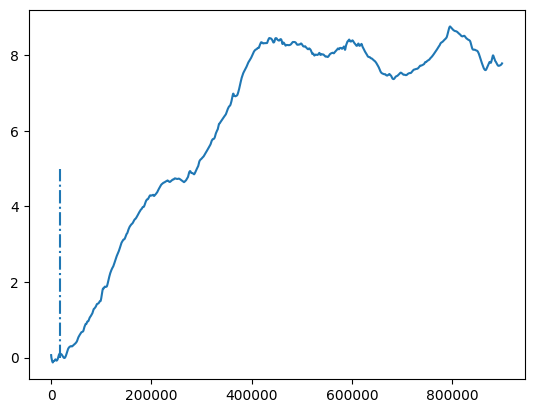

cropping at  17407


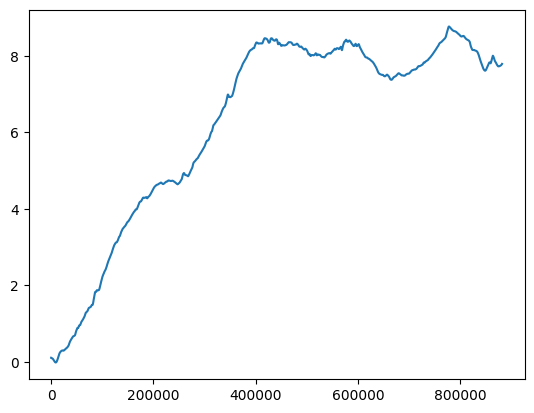

0.0651702030392393


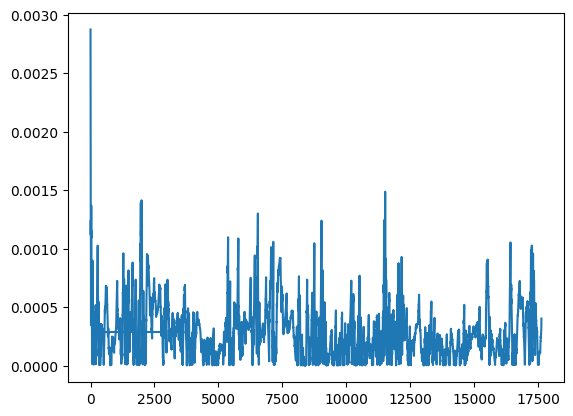

In [166]:

df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 51  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# 2.18 mM


Data length: 322748 samples
Testing window sizes for changepoint detection quality...

Optimal window size: 51
Best quality score: 1.629
Original fixed window: 25
Original window (25) score: 1.529


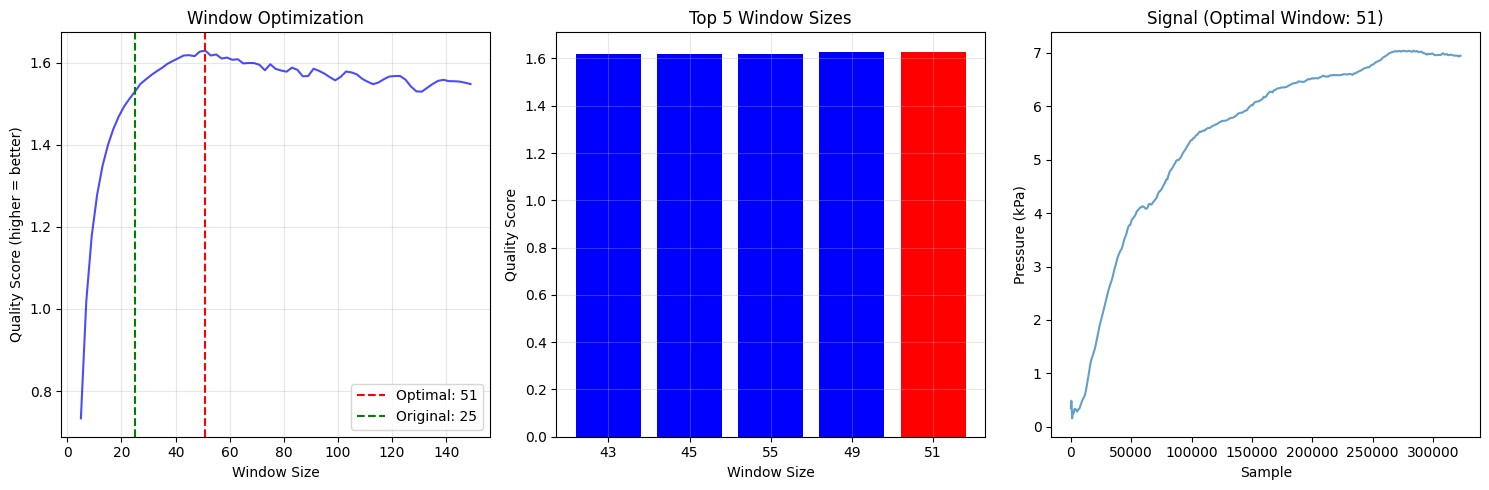


Selected window size: 51
Improvement over original: 6.5% better


In [168]:
# Approach 2: Optimization-based Window Selection
# This approach finds the window size that gives the BEST changepoint detection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data (keep your existing loading code)
df = pd.read_csv( r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv",
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]

print(f"Data length: {len(pressure)} samples")

# Method 2: Optimize window size by testing changepoint detection quality
# We'll run your exact algorithm with different windows and see which gives best separation

def test_changepoint_quality(pressure, window_size):
    """
    Test how well a window size works for changepoint detection
    Returns a quality score (higher = better)
    """
    window = int(window_size)
    
    # Skip if window is too small or too big
    if window < 5 or window > len(pressure)//5:
        return -999  # Very bad score
    
    try:
        # Your original algorithm
        std_all = []
        for i in range(0, len(pressure)-window, window):
            arr1 = pressure[i:i+window]
            std_all.append(np.std(arr1))
        
        # Need at least 3 windows to make sense
        if len(std_all) < 3:
            return -999
        
        mean_std = np.mean(std_all)
        threshold = mean_std + np.std(std_all)
        
        # Quality metrics:
        # 1. How well separated are the "change" regions from "stable" regions?
        separation = np.std(std_all) / (mean_std + 1e-10)
        
        # 2. Do we have a reasonable number of windows? (not too few, not too many)
        ideal_num_windows = len(pressure) // 50  # rough target
        window_penalty = abs(len(std_all) - ideal_num_windows) / ideal_num_windows
        
        # Combine scores (higher = better)
        quality_score = separation - 0.1 * window_penalty
        
        return quality_score
        
    except:
        return -999  # Error = bad score

# Test different window sizes
test_windows = range(5, min(150, len(pressure)//5), 2)  # Test more windows, step by 2
quality_scores = []

print("Testing window sizes for changepoint detection quality...")

for window in test_windows:
    score = test_changepoint_quality(pressure, window)
    quality_scores.append(score)
    
    if window % 20 == 0:  # Progress update
        print(f"  Tested up to window size {window}...")

# Find the best window size
best_idx = np.argmax(quality_scores)
optimal_window = list(test_windows)[best_idx]
best_score = quality_scores[best_idx]

print(f"\nOptimal window size: {optimal_window}")
print(f"Best quality score: {best_score:.3f}")
print(f"Original fixed window: 25")

# Compare with original window
original_score = test_changepoint_quality(pressure, 25)
print(f"Original window (25) score: {original_score:.3f}")

# Visualize the optimization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(test_windows, quality_scores, 'b-', alpha=0.7)
plt.axvline(optimal_window, color='r', linestyle='--', label=f'Optimal: {optimal_window}')
plt.axvline(25, color='g', linestyle='--', label='Original: 25')
plt.xlabel('Window Size')
plt.ylabel('Quality Score (higher = better)')
plt.title('Window Optimization')
plt.legend()
plt.grid(True, alpha=0.3)

# Show top 5 window sizes
top_5_indices = np.argsort(quality_scores)[-5:]
top_5_windows = [list(test_windows)[i] for i in top_5_indices]
top_5_scores = [quality_scores[i] for i in top_5_indices]

plt.subplot(1, 3, 2)
bars = plt.bar(range(5), top_5_scores, color=['red' if w == optimal_window else 'blue' for w in top_5_windows])
plt.xticks(range(5), [f'{w}' for w in top_5_windows])
plt.xlabel('Window Size')
plt.ylabel('Quality Score')
plt.title('Top 5 Window Sizes')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(pressure, alpha=0.7)
plt.title(f'Signal (Optimal Window: {optimal_window})')
plt.xlabel('Sample')
plt.ylabel('Pressure (kPa)')

plt.tight_layout()
plt.show()

# Store the result for next cell
selected_window = optimal_window
print(f"\nSelected window size: {selected_window}")
print(f"Improvement over original: {((best_score - original_score) / abs(original_score) * 100):.1f}% better" if original_score != -999 else "Much better than original")

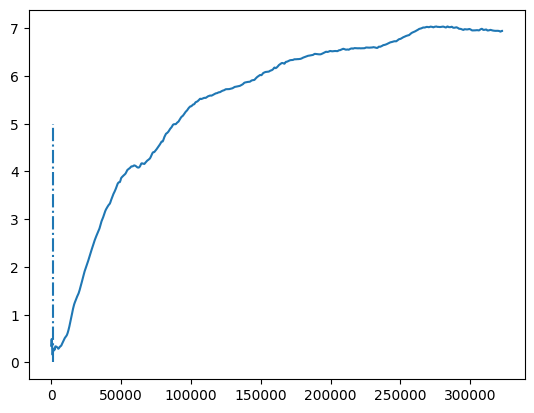

cropping at  1600


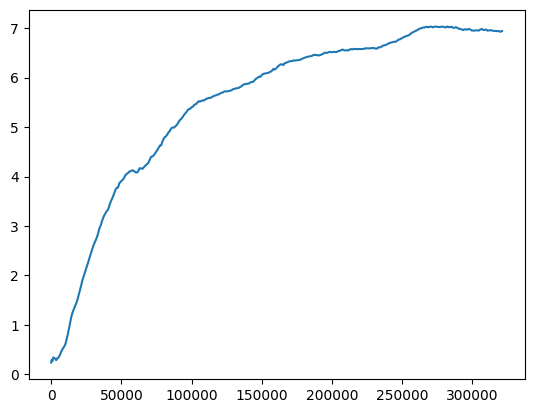

0.12051913539577576


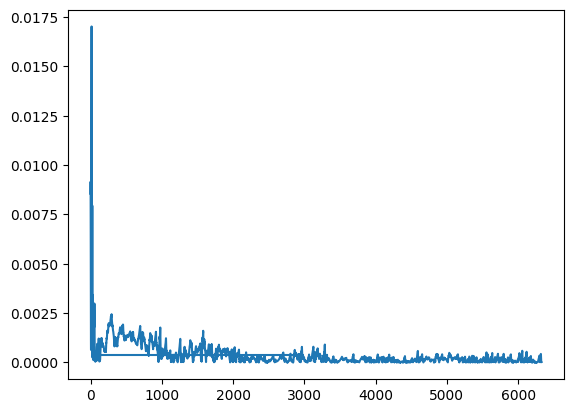

In [137]:

df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 51  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

Data length: 268572 samples
Testing window sizes for changepoint detection quality...

Optimal window size: 49
Best quality score: 2.913
Original fixed window: 25
Original window (25) score: 2.810


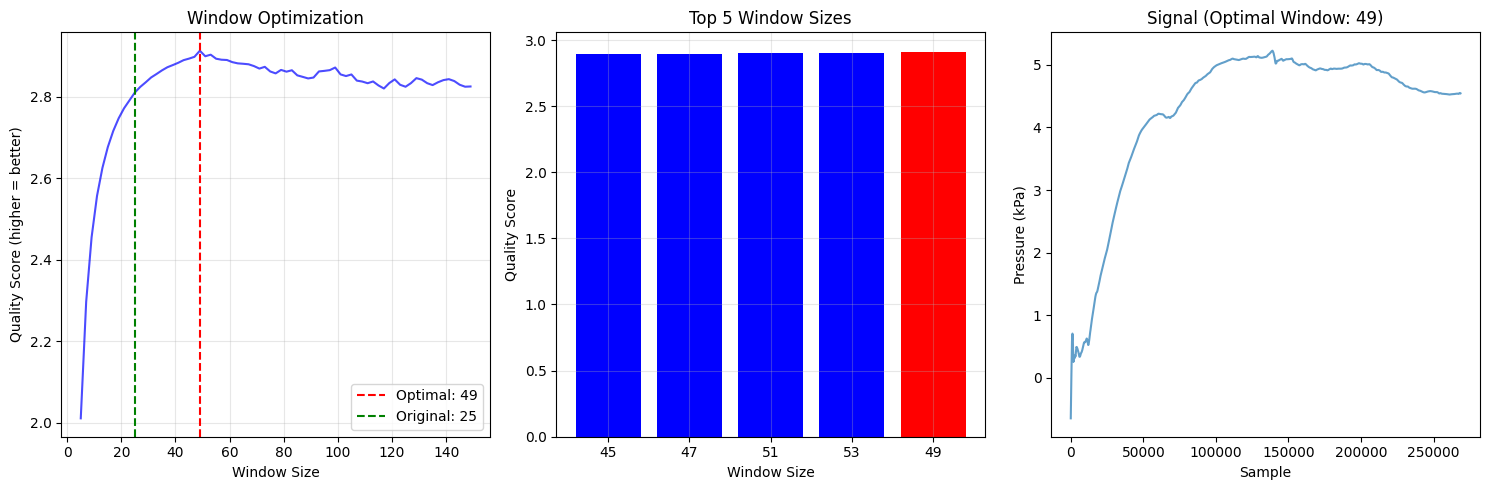


Selected window size: 49
Improvement over original: 3.6% better


In [138]:
# Approach 2: Optimization-based Window Selection
# This approach finds the window size that gives the BEST changepoint detection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data (keep your existing loading code)
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv",
                 on_bad_lines='skip')
time = df["Time (h)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]

print(f"Data length: {len(pressure)} samples")

# Method 2: Optimize window size by testing changepoint detection quality
# We'll run your exact algorithm with different windows and see which gives best separation

def test_changepoint_quality(pressure, window_size):
    """
    Test how well a window size works for changepoint detection
    Returns a quality score (higher = better)
    """
    window = int(window_size)
    
    # Skip if window is too small or too big
    if window < 5 or window > len(pressure)//5:
        return -999  # Very bad score
    
    try:
        # Your original algorithm
        std_all = []
        for i in range(0, len(pressure)-window, window):
            arr1 = pressure[i:i+window]
            std_all.append(np.std(arr1))
        
        # Need at least 3 windows to make sense
        if len(std_all) < 3:
            return -999
        
        mean_std = np.mean(std_all)
        threshold = mean_std + np.std(std_all)
        
        # Quality metrics:
        # 1. How well separated are the "change" regions from "stable" regions?
        separation = np.std(std_all) / (mean_std + 1e-10)
        
        # 2. Do we have a reasonable number of windows? (not too few, not too many)
        ideal_num_windows = len(pressure) // 50  # rough target
        window_penalty = abs(len(std_all) - ideal_num_windows) / ideal_num_windows
        
        # Combine scores (higher = better)
        quality_score = separation - 0.1 * window_penalty
        
        return quality_score
        
    except:
        return -999  # Error = bad score

# Test different window sizes
test_windows = range(5, min(150, len(pressure)//5), 2)  # Test more windows, step by 2
quality_scores = []

print("Testing window sizes for changepoint detection quality...")

for window in test_windows:
    score = test_changepoint_quality(pressure, window)
    quality_scores.append(score)
    
    if window % 20 == 0:  # Progress update
        print(f"  Tested up to window size {window}...")

# Find the best window size
best_idx = np.argmax(quality_scores)
optimal_window = list(test_windows)[best_idx]
best_score = quality_scores[best_idx]

print(f"\nOptimal window size: {optimal_window}")
print(f"Best quality score: {best_score:.3f}")
print(f"Original fixed window: 25")

# Compare with original window
original_score = test_changepoint_quality(pressure, 25)
print(f"Original window (25) score: {original_score:.3f}")

# Visualize the optimization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(test_windows, quality_scores, 'b-', alpha=0.7)
plt.axvline(optimal_window, color='r', linestyle='--', label=f'Optimal: {optimal_window}')
plt.axvline(25, color='g', linestyle='--', label='Original: 25')
plt.xlabel('Window Size')
plt.ylabel('Quality Score (higher = better)')
plt.title('Window Optimization')
plt.legend()
plt.grid(True, alpha=0.3)

# Show top 5 window sizes
top_5_indices = np.argsort(quality_scores)[-5:]
top_5_windows = [list(test_windows)[i] for i in top_5_indices]
top_5_scores = [quality_scores[i] for i in top_5_indices]

plt.subplot(1, 3, 2)
bars = plt.bar(range(5), top_5_scores, color=['red' if w == optimal_window else 'blue' for w in top_5_windows])
plt.xticks(range(5), [f'{w}' for w in top_5_windows])
plt.xlabel('Window Size')
plt.ylabel('Quality Score')
plt.title('Top 5 Window Sizes')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(pressure, alpha=0.7)
plt.title(f'Signal (Optimal Window: {optimal_window})')
plt.xlabel('Sample')
plt.ylabel('Pressure (kPa)')

plt.tight_layout()
plt.show()

# Store the result for next cell
selected_window = optimal_window
print(f"\nSelected window size: {selected_window}")
print(f"Improvement over original: {((best_score - original_score) / abs(original_score) * 100):.1f}% better" if original_score != -999 else "Much better than original")

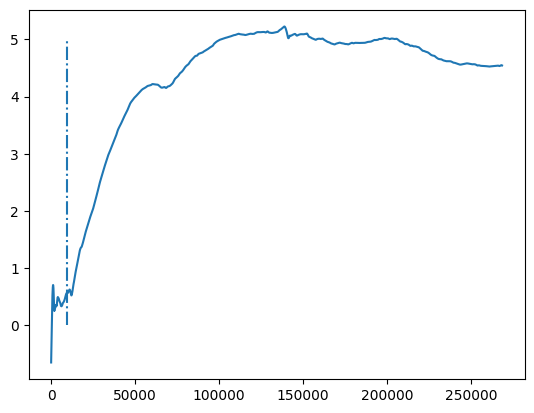

cropping at  9395


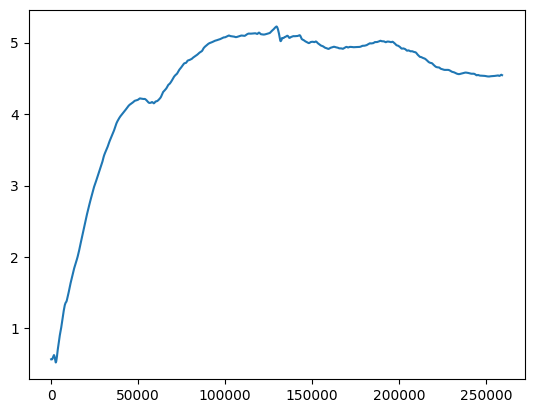

0.1960365581505114


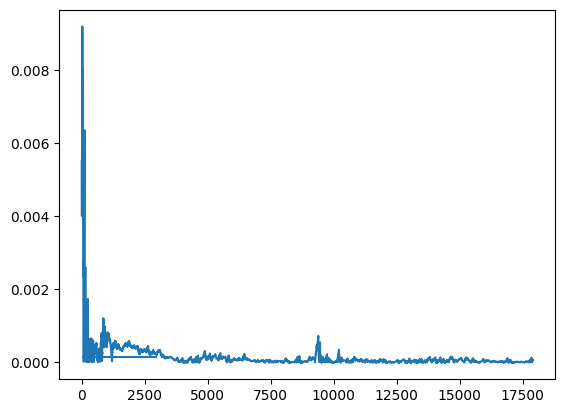

In [189]:

df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (h)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 15  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# Understanding

# Algorithm suggested (window_size =50)

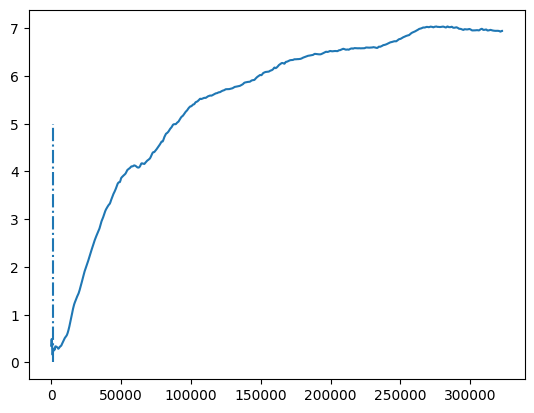

cropping at  1600


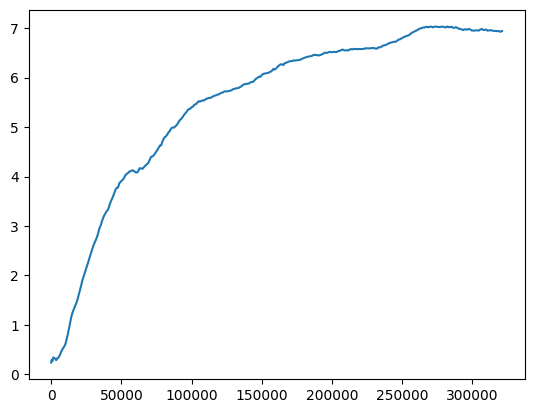

0.12051913539577576


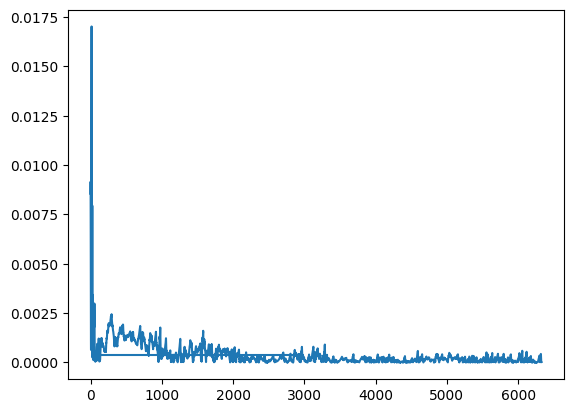

In [169]:

df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 51  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# Handpicked (window_size = 25)

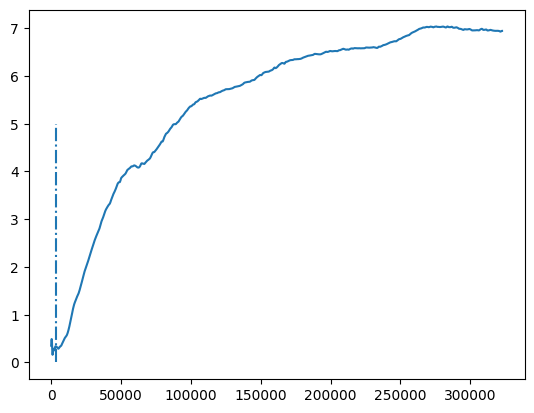

cropping at  3265


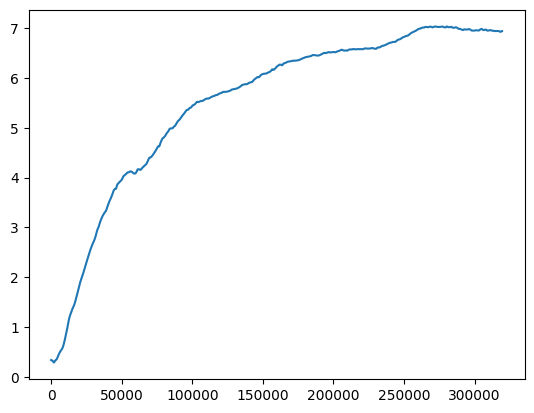

0.08749701870206071


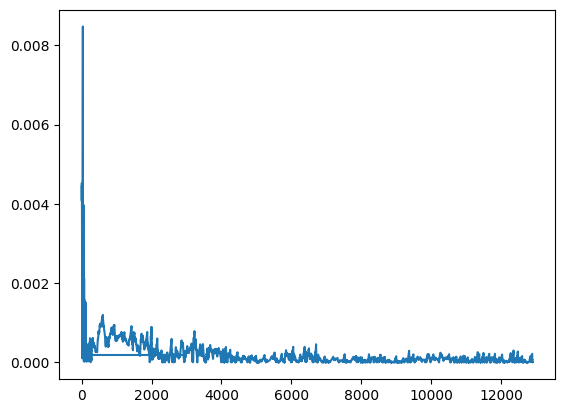

In [170]:

df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 25  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# window size 10 = 17

In [270]:
# Approach 2: Optimization-based Window Selection
# This approach finds the window size that gives the BEST changepoint detection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data (keep your existing loading code)
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv",
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]



def test_changepoint_quality(pressure, window_size):
    """
    Test how well a window size works for changepoint detection
    Returns a quality score (higher = better)
    """
    window = int(window_size)
    
    # Skip if window is too small or too big
    if window < 5 or window > len(pressure)//5:
        return -999  # Very bad score
    
    try:
        
        std_all = []
        for i in range(0, len(pressure)-window, window):
            arr1 = pressure[i:i+window]
            std_all.append(np.std(arr1))
        
        # Need at least 3 windows to make sense
        if len(std_all) < 3:
            return -999
        
        mean_std = np.mean(std_all)
        threshold = mean_std + np.std(std_all)
        
        # Quality metrics:
        # 1. How well separated are the "change" regions from "stable" regions?
        separation = np.std(std_all) / (mean_std + 1e-10)
        
        # 2. Do we have a reasonable number of windows? (not too few, not too many)
        ideal_num_windows = len(pressure) // 50  # rough target
        window_penalty = abs(len(std_all) - ideal_num_windows) / ideal_num_windows
        
        # Combine scores (higher = better)
        quality_score = separation - 0.1 * window_penalty
        
        return quality_score
        
    except:
        return -999  # Error = bad score

# Test different window sizes
test_windows = range(10, 16)  
quality_scores = []

print("Testing window sizes for changepoint detection quality...")

for window in test_windows:
    score = test_changepoint_quality(pressure, window)
    quality_scores.append(score)
   

# Find the best window size
best_idx = np.argmax(quality_scores)
optimal_window = list(test_windows)[best_idx]
best_score = quality_scores[best_idx]



# Store the result for next cell
selected_window = optimal_window
print(f"\nSelected window size: {selected_window}")


Testing window sizes for changepoint detection quality...

Selected window size: 15


In [ ]:
# df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv", 
#                  on_bad_lines='skip')
# time = df["Time (s)"]
# pressure = df["DWT denoised pressure (kPa)"]
# time = time.values[:]
# pressure = pressure.values[:]
# window = selected_window #no of samples
# # std_all = np.std(pressure)
# std_all=[]
# for i in range(0,len(pressure)-window,window):
#     arr1 = pressure[i:i+window]
#     # print(np.std(arr1))
#     std_all.append(np.std(arr1))
#     # if np.std(arr1)>std_all:
#     #     crop_idx = i
# mean_std = np.mean(std_all)
# thres = mean_std+np.std(std_all)
# for i in std_all:
#     if i>thres:
#         cut_idx = i
# for i in range(0,len(std_all)):
#     if std_all[i]==cut_idx:
#         crop_idx = i
        
        
        
# plt.plot(pressure)
# plt.vlines(crop_idx,0,5,linestyles="dashdot")
# plt.title('Pressure with detected changepoint')
# plt.legend(["Pressure with initial sensor noise"])
# plt.show()
# weed = pressure[:crop_idx]
# pressure = pressure[crop_idx:]

# print("cropping at ", crop_idx)
# plt.plot(pressure, linewidth=2.0)
# plt.title('Pressure vs Time after removing initial unstable region')
# plt.legend(["Pressure with initial sensor noise removed"])
# plt.show()

# # print(np.abs(np.std(weed)-mean_std))
# plt.plot(std_all)
# plt.title("Standard Deviation of Pressure throughout the experiment")
# plt.hlines(mean_std,0,3000)
# plt.show()






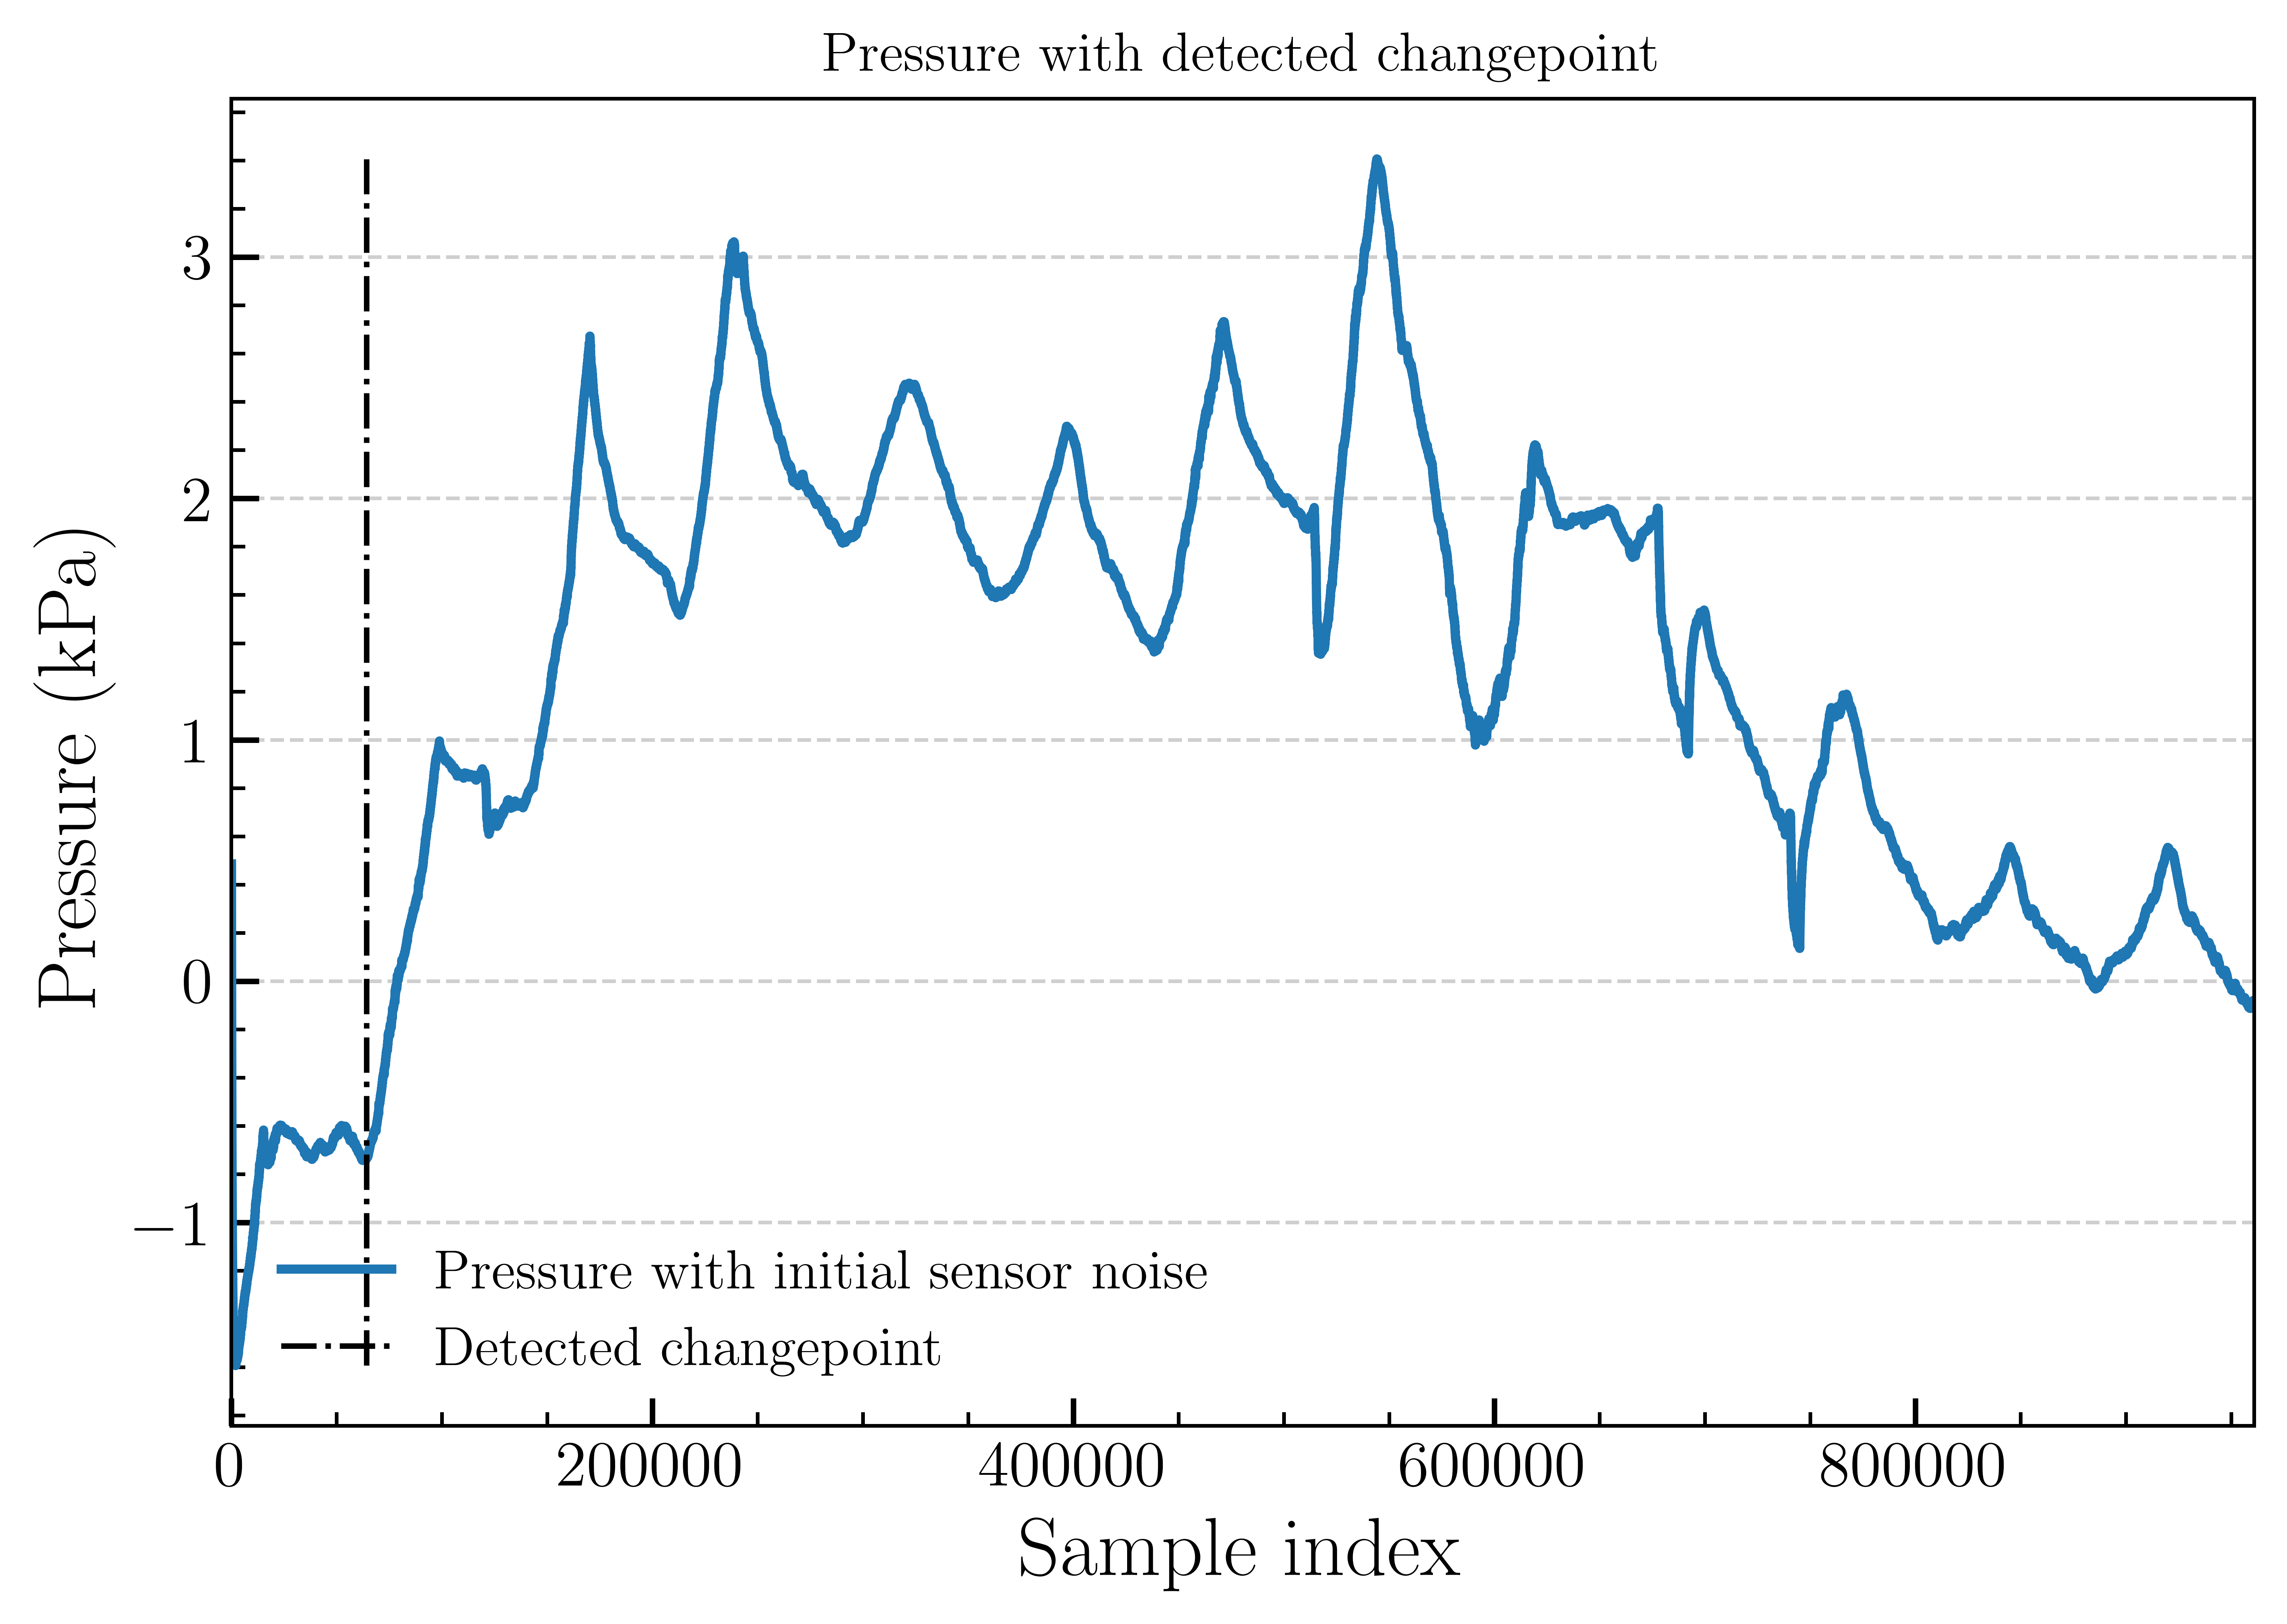

    Time (s)  Pressure_BC (kPa)
0  20.609722            -0.7350
1  20.610000            -0.7350
2  20.610278            -0.7353
3  20.610833            -0.7360
4  20.611111            -0.7359


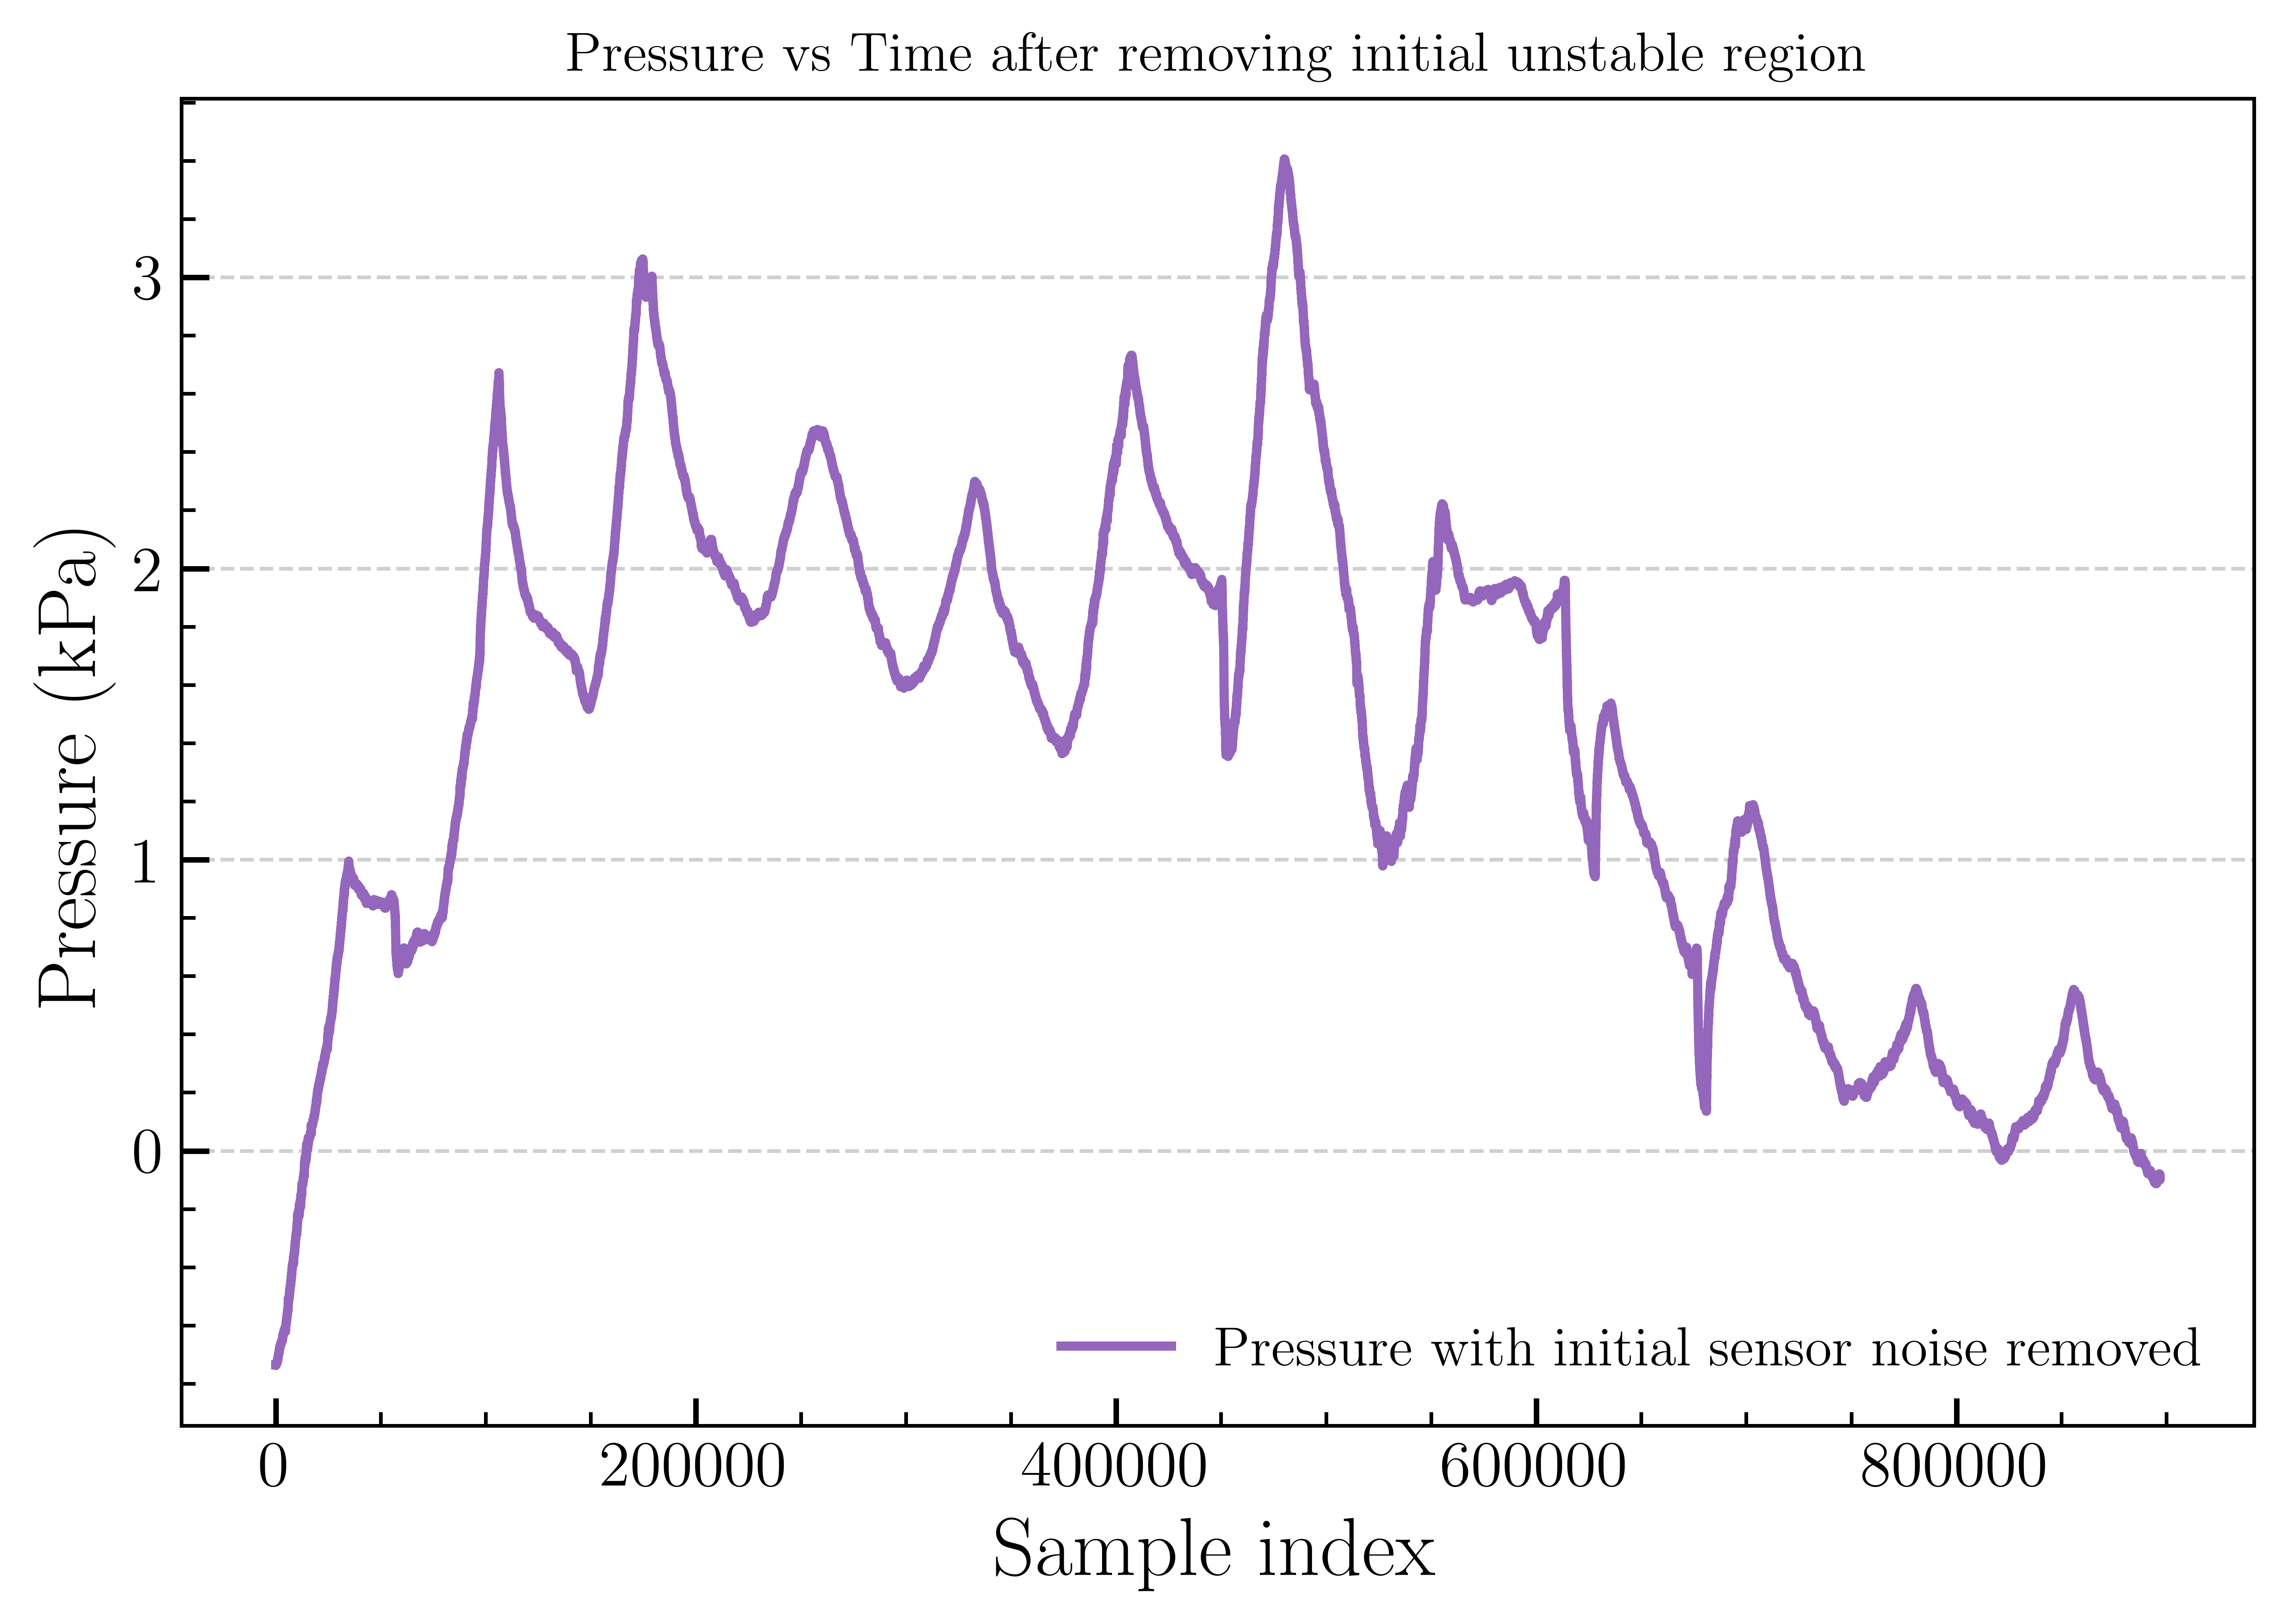

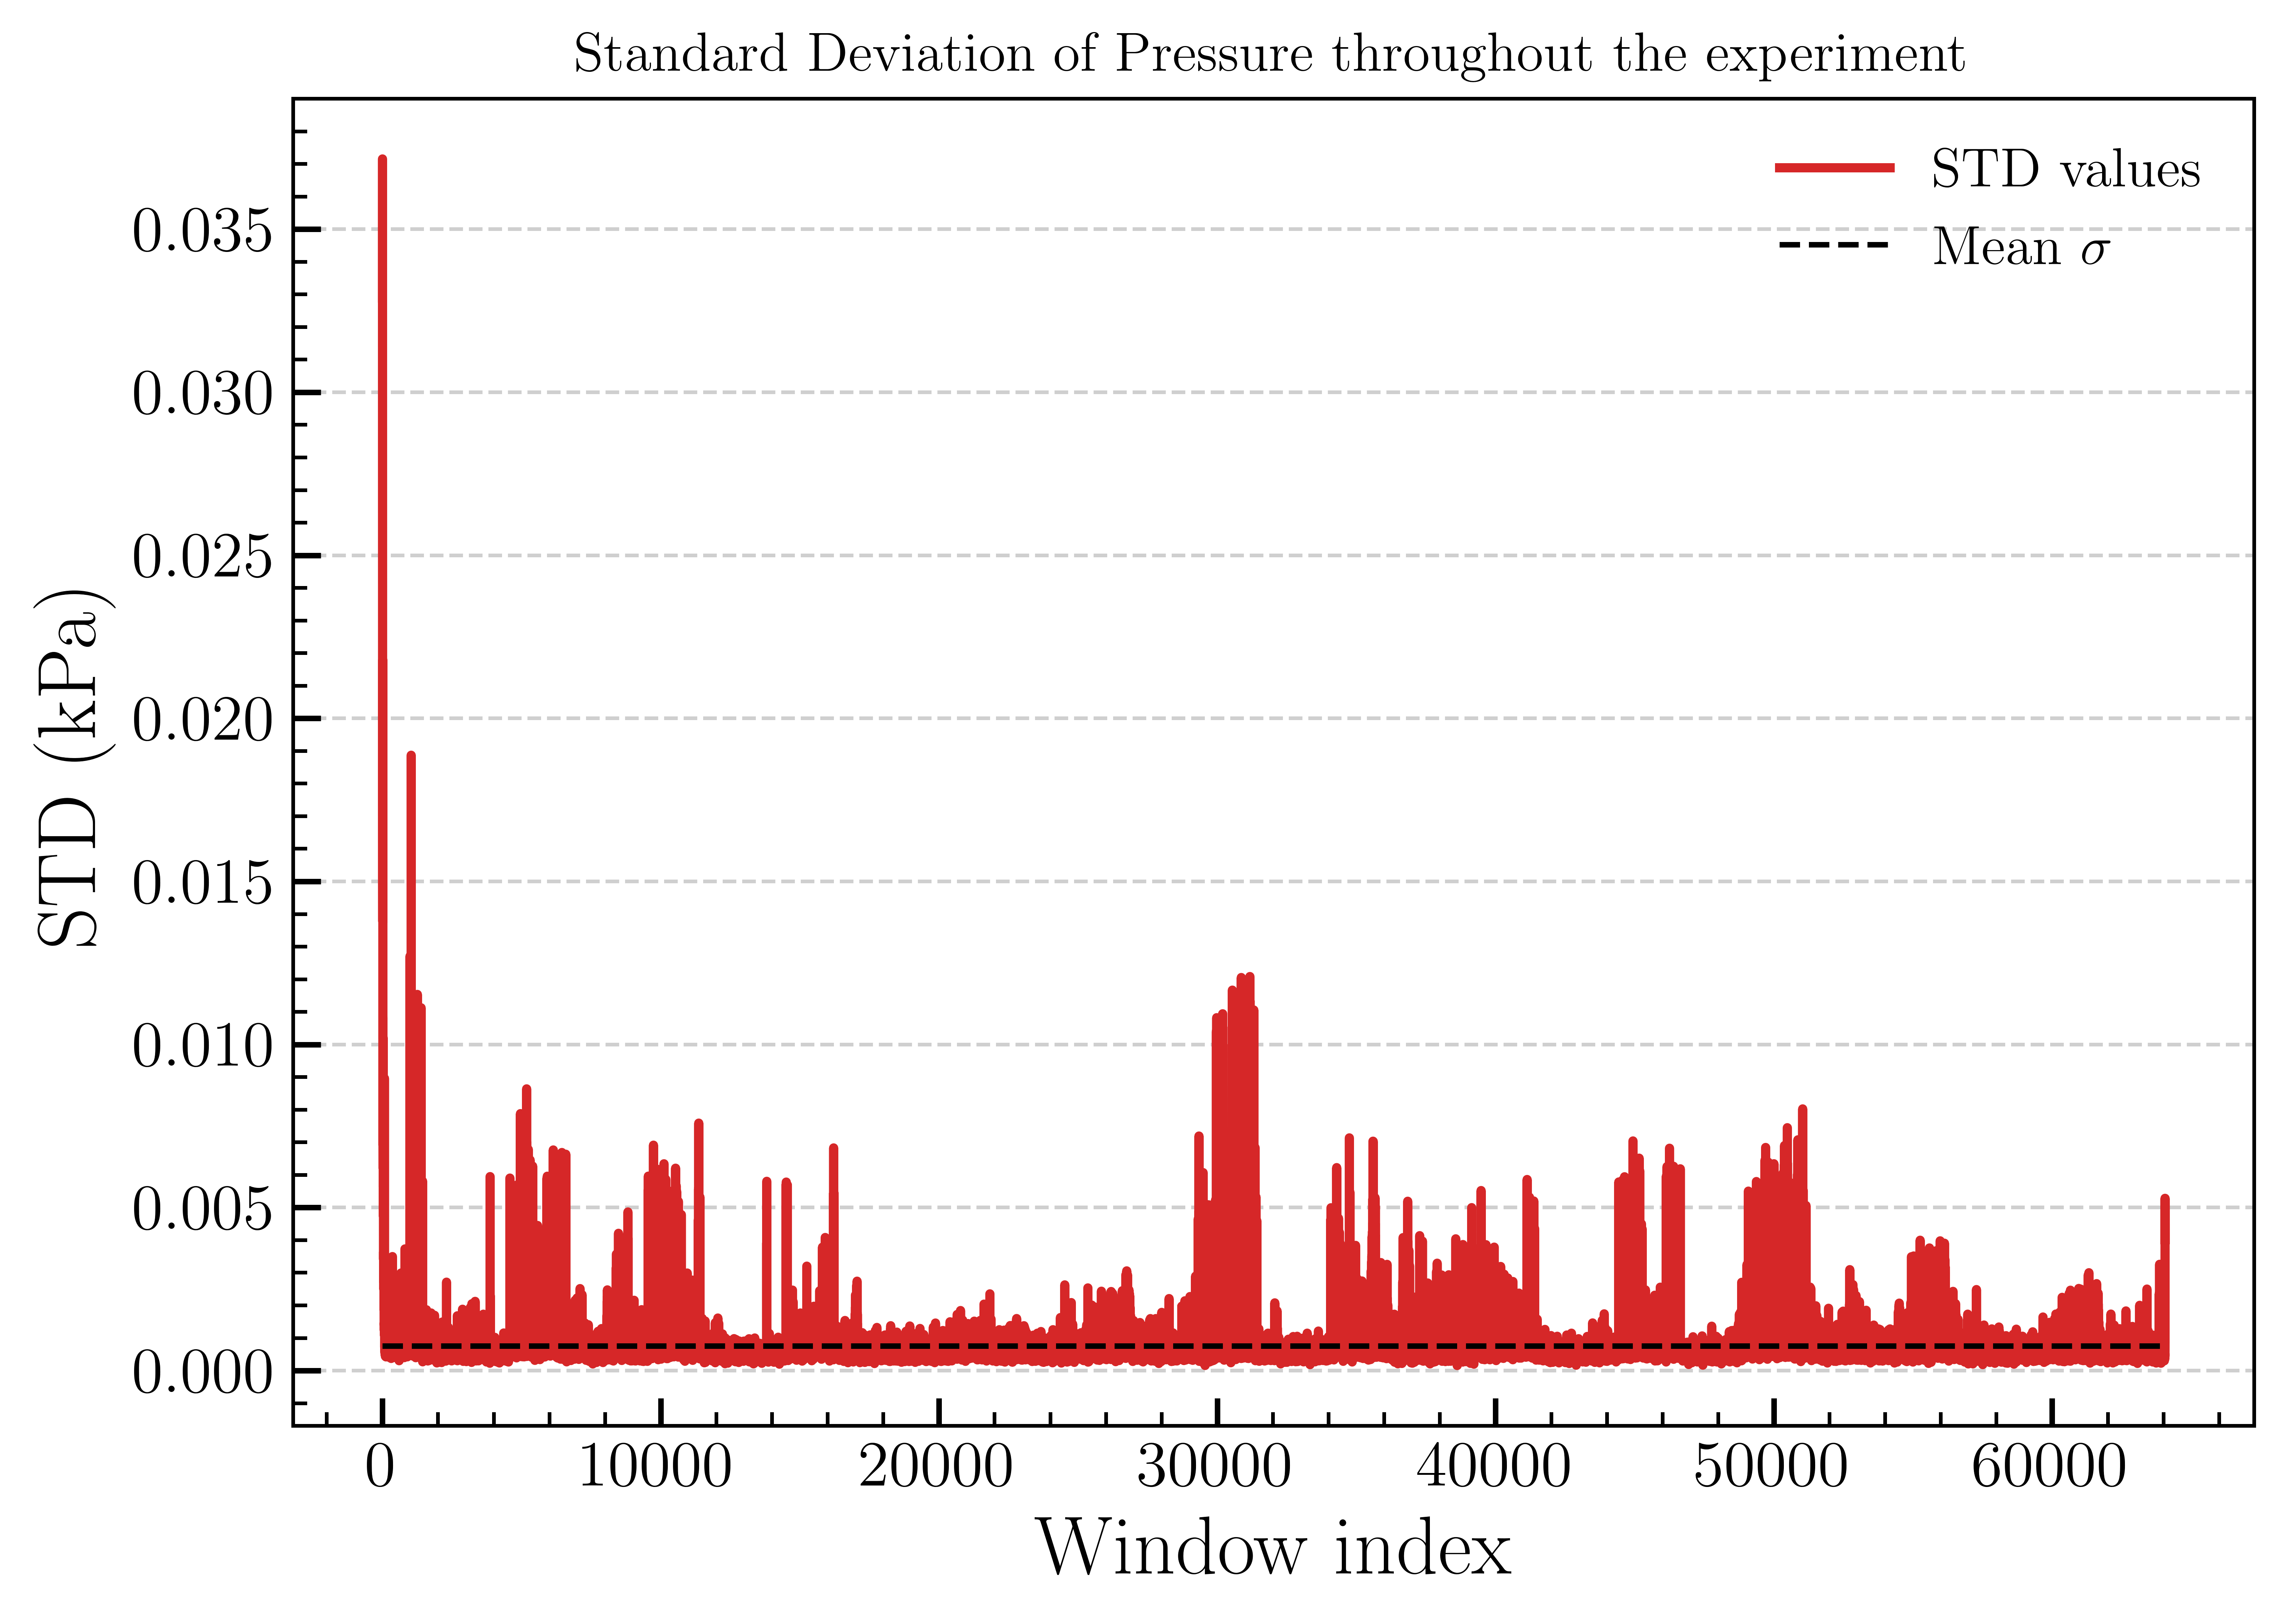

In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 900

# ========= Load data =========
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"].values[:]
pressure = df["DWT denoised pressure (kPa)"].values[:]



window = selected_window  # no of samples

# ========= STD detection (unchanged) =========
std_all = []
for i in range(0, len(pressure) - window, window):
    arr1 = pressure[i:i+window]
    std_all.append(np.std(arr1))

mean_std = np.mean(std_all)
thres = mean_std + np.std(std_all)


for i in std_all:
    if i > thres:
        cut_idx = i
for i in range(0, len(std_all)):
    if std_all[i] == cut_idx:
        crop_idx = i

# ========= Helper function for consistent axis style =========
def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))

# ========= Plot 1 =========
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(pressure, lw=2.0, color="tab:blue", label=r'Pressure with initial sensor noise')
ax1.vlines(crop_idx, ymin=np.min(pressure), ymax=np.max(pressure), 
           linestyles="dashdot", linewidth=1.2, color="k", label="Detected changepoint")

ax1.set_title(r'Pressure with detected changepoint')
style_axes(ax1, xlabel="Sample index", ylabel="Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
ax1.set_xlim(0, len(pressure))
plt.tight_layout()
plt.show()

# ========= Crop =========
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]

time = time[crop_idx:]              # <— slice time to match
df_corrected = pd.DataFrame({
    "Time (s)": time,
    "Pressure_BC (kPa)": pressure
})
print(df_corrected.head())

# ========= Plot 2 =========
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(pressure, linewidth=2.0, color="tab:purple", label=r'Pressure with initial sensor noise removed')

ax1.set_title(r'Pressure vs Time after removing initial unstable region')
style_axes(ax1, xlabel="Sample index", ylabel="Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

# ========= Plot 3 =========
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(std_all, lw=2.0, color="tab:red", label="STD values")
ax1.hlines(mean_std, xmin=0, xmax=len(std_all)-1, linestyles='--', linewidth=1.2, color="k", label=r'Mean $\sigma$')

ax1.set_title(r'Standard Deviation of Pressure throughout the experiment')
style_axes(ax1, xlabel="Window index", ylabel="STD (kPa)")
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()



# Baseline corrected:

   Time (s)  Pressure_BC (kPa)
0  0.000000           0.007642
1  0.000278           0.007598
2  0.000556           0.007554
3  0.000833           0.007510
4  0.001111           0.007466


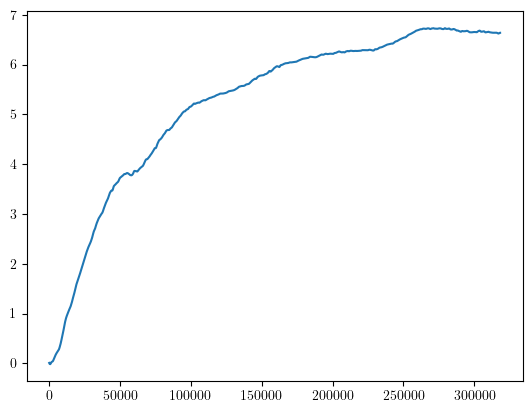

In [ ]:
import pandas as pd
import numpy as np

# Assuming your original dataframe is already created as df_corrected
# df_corrected = pd.DataFrame({
#     "Time (s)": time,
#     "Pressure_BC (kPa)": pressure
# })

start_time = df_corrected["Time (s)"].iloc[0]
df_corrected["Time (s)"] = df_corrected["Time (s)"] - start_time
baseline_data = df_corrected[df_corrected["Time (s)"] <= 0.0833]
baseline_pressure = baseline_data["Pressure_BC (kPa)"].mean()


df_corrected["Pressure_BC (kPa)"] = df_corrected["Pressure_BC (kPa)"] - baseline_pressure

# Print the head of the corrected DataFrame to show the result
# print(df_corrected.head())
# plt.plot(df_corrected["Pressure_BC (kPa)"])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 900

# ========= Load data =========
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"].values[:]
pressure = df["DWT denoised pressure (kPa)"].values[:]

window = selected_window  # no of samples

# ========= STD detection (unchanged) =========
std_all = []
for i in range(0, len(pressure) - window, window):
    arr1 = pressure[i:i+window]
    std_all.append(np.std(arr1))

mean_std = np.mean(std_all)
thres = mean_std + np.std(std_all) #0.00035871690539713804

for i in std_all:
    if i > thres:
        cut_idx = i
for i in range(0, len(std_all)):
    if std_all[i] == cut_idx:
        crop_idx = i
        

# ========= Helper function for consistent axis style =========
def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))
      
   

# # ========= Plot 1 =========
# fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)

# ax1.plot(time, pressure, lw=2.0, color="tab:blue", label=r'Pressure with initial sensor noise')
# ax1.vlines(time[crop_idx], ymin=np.min(pressure), ymax=np.max(pressure), 
#            linestyles="dashdot", linewidth=1.2, color="k", label="Detected changepoint")
# ax1.set_title(r'Pressure with detected changepoint in M2-2.18mM at 37$^\circ$C')
# style_axes(ax1, xlabel="Elapsed time (h)", ylabel="Pressure (kPa)", y_major=1.0)
# ax1.legend(frameon=False, fontsize=12, loc="right")
# ax1.set_xlim() 
# ax1.set_ylim()  
# plt.tight_layout()
# plt.show()


# ========= Crop =========
weed = pressure[:crop_idx]

pressure = pressure[crop_idx:]
time = time[crop_idx:]              # <— slice time to match
df_corrected = pd.DataFrame({
    "Time (s)": time,
    "Pressure_BC (kPa)": pressure
})
start_time = df_corrected["Time (s)"].iloc[0]
df_corrected["Time (s)"] = df_corrected["Time (s)"] - start_time
baseline_data = df_corrected[df_corrected["Time (s)"] <= 0.0833]
baseline_pressure = baseline_data["Pressure_BC (kPa)"].mean()
df_corrected["Pressure_BC (kPa)"] = df_corrected["Pressure_BC (kPa)"] - baseline_pressure

# ========= Plot 2 =========
# fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
# ax1.plot(df_corrected["Time (s)"], df_corrected["Pressure_BC (kPa)"], linewidth=2.0, color="tab:purple", label=r'Pressure with initial sensor noise removed ')

# ax1.set_title(r'Pressure vs Time after removing initial unstable region in M2-2.18mM at 37$^\circ$C')
# style_axes(ax1, xlabel="Elapsed time (h)", ylabel="Pressure (kPa)", y_major=1.0)
# ax1.legend(frameon=False, fontsize=12, loc="best")
# plt.tight_layout()
# plt.show()

# # ========= Plot 3 =========
# fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
# ax1.plot(std_all, lw=2.0, color="tab:red", label="Standard deviation values")
# ax1.hlines(mean_std, xmin=0, xmax=len(std_all)-1, linestyles='--', linewidth=1.2, color="k", label=r'Mean $\sigma$')

# ax1.set_title(r'Standard Deviation of Pressure throughout the experiment in M2-2.18mM at 37$^\circ$C')
# style_axes(ax1, xlabel="Data segments", ylabel="Standard deviation (kPa)")
# ax1.legend(frameon=False, fontsize=12, loc="best")
# plt.tight_layout()
# plt.show()


In [262]:
print(thres)

0.00035871690539713804


In [266]:
print(len(std_all))
print(mean_std)

17930
0.00013625951095583722


In [267]:
a = np.std(std_all) 
print(a)

0.0002224573944413008


# Use this code block if you want only one 0 in the origin

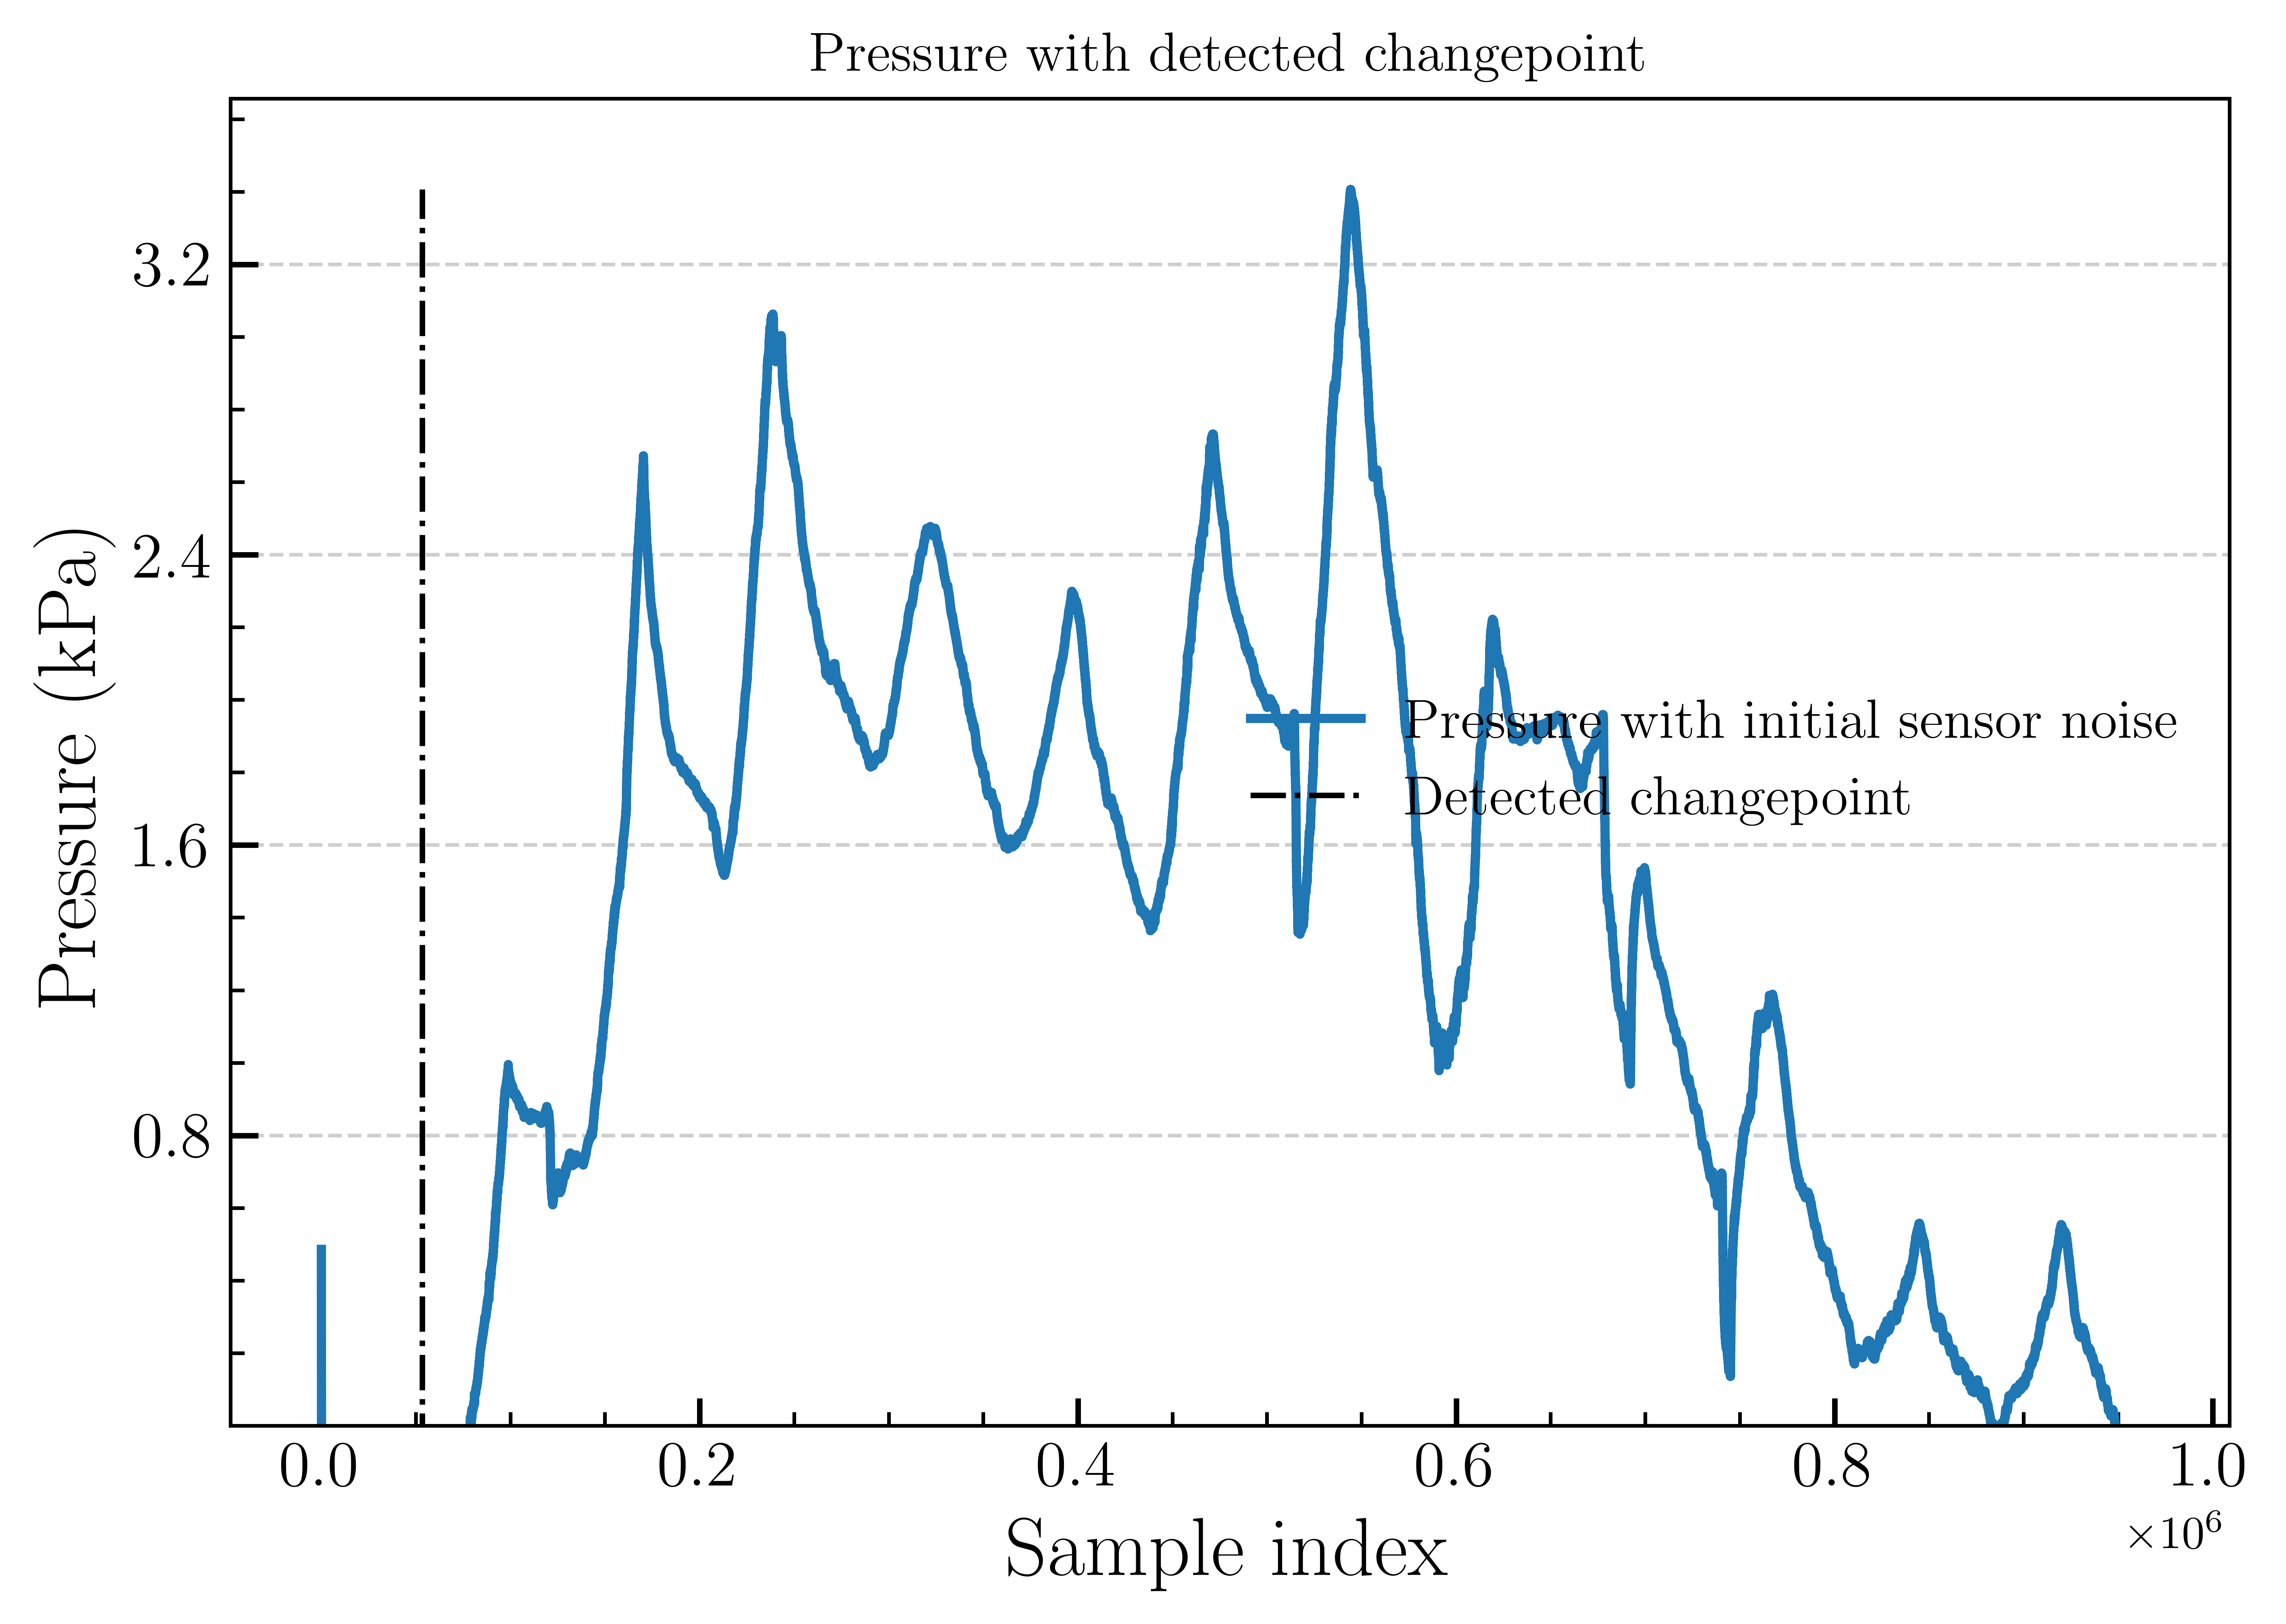

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator

# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 900

# ========= Load data =========
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_RT\raw_meas\merged_pressure_log_RT.csv",
                 on_bad_lines='skip')
time = df["Elapsed Time (hours)"].values[:]
pressure = df[ "ABP2-Sch1 (kPa)"].values[:]

window = selected_window  # no of samples

# ========= STD detection (unchanged) =========
std_all = []
for i in range(0, len(pressure) - window, window):
    arr1 = pressure[i:i+window]
    std_all.append(np.std(arr1))

mean_std = np.mean(std_all)
thres = mean_std + np.std(std_all)

for i in std_all:
    if i > thres:
        cut_idx = i
for i in range(0, len(std_all)):
    if std_all[i] == cut_idx:
        crop_idx = i


# ========= Helper function for consistent axis style =========
def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))


# ========= Plot 1 =========
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)

ax1.plot(pressure, lw=2.0, color="tab:blue", label=r'Pressure with initial sensor noise')
ax1.vlines(crop_idx, ymin=np.min(pressure), ymax=np.max(pressure),
           linestyles="dashdot", linewidth=1.2, color="k", label="Detected changepoint")

ax1.set_title(r'Pressure with detected changepoint')
style_axes(ax1, xlabel="Sample index", ylabel="Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="right")

ax1.set_xlim()
ax1.set_ylim(0, ax1.get_ylim()[1])

# --- Use MaxNLocator to remove the lower tick label on the y-axis ---
ax1.yaxis.set_major_locator(MaxNLocator(prune='lower', nbins=5))

plt.tight_layout()
plt.show()